In [17]:
from langgraph.graph import START,StateGraph,END
from typing import TypedDict,Literal

In [2]:
class QuadState(TypedDict):

    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str

In [14]:
def show_eq(state:QuadState):
    equation=f'{state["a"]}x2 + {state["b"]}x+ {state["c"]}'
    return {"equation":equation}

In [6]:
def cal_dis(state:QuadState):
    a=state["a"]
    b=state["b"]
    c=state["c"]

    d=(b**2)-(4*a*c)

    return {"discriminant":d}

In [16]:
def real_root(state:QuadState):

    root1= (-state["b"]+state["discriminant"]**0.5)/(2*state["a"])
    root2= (-state["b"]-state["discriminant"]**0.5)/(2*state["a"])
    result=f'the roots are {root1} and {root2}'
    return {"result":result}

def same_root(state:QuadState):

    root= (-state["b"])/(2*state["a"])
    result=f'the root is {root}'
    return {"result":result}

def no_root(state:QuadState):
    return {"result":"No Real roots"}

In [18]:
def check_cond(state:QuadState) -> Literal["real_root","same_root","no_root"]:
    if state["discriminant"]>0:
        return "real_root"
    elif state["discriminant"] == 0:
        return "same_root"
    else:
        return "no_root"

In [19]:
graph=StateGraph(QuadState)

graph.add_node("show_eq",show_eq)
graph.add_node("cal_ds",cal_dis)
graph.add_node("real_root",real_root)
graph.add_node("same_root",same_root)
graph.add_node("no_root",no_root)


graph.add_edge(START,"show_eq")
graph.add_edge("show_eq","cal_ds")
graph.add_conditional_edges("cal_ds",check_cond)
graph.add_edge(["real_root","same_root","no_root"],END)

workflow=graph.compile()

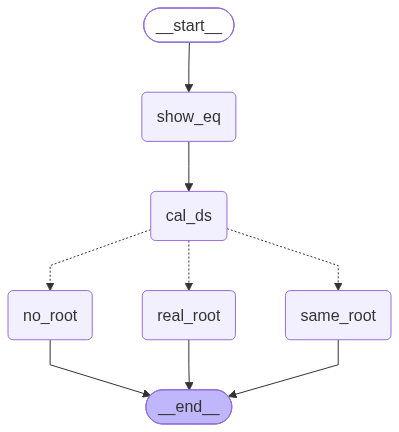

In [20]:
workflow

In [30]:
intial_state={
    "a":1,
    "b":-1,
    "c":20
}
workflow.invoke(intial_state)

{'a': 1,
 'b': -1,
 'c': 20,
 'equation': '1x2 + -1x+ 20',
 'discriminant': -79,
 'result': 'No Real roots'}